# Artificial Neural Networks 
## Assignment 2
### Saad Karim      22P-9277
### Task 0

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

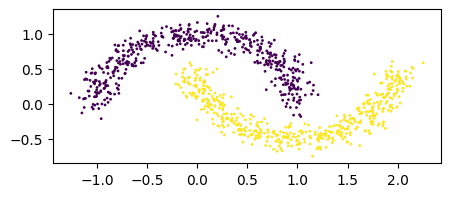

In [3]:
points = np.genfromtxt('cluster_moons.csv', delimiter=',')
points = points[1:len(points)]
x = points[:,0]
y = points[:,1]
labels = points[:,2]
plt.figure(figsize=(5,2))
plt.scatter(x, y, c=labels, s=1)
plt.show()

In [5]:
inputs = np.column_stack((x, y))
outputs = labels.reshape(-1, 1)

In [6]:
num_input_features = inputs.shape[1]
input_length = inputs.shape[0]

print(f"Question 1: The inputs variable has {num_input_features} features and a length of {input_length}")

Question 1: The inputs variable has 2 features and a length of 1000


In [7]:
num_output_features = outputs.shape[1]
output_length = outputs.shape[0]

print(f"Question 2: The outputs variable has {num_output_features} feature and a length of {output_length}")


Question 2: The outputs variable has 1 feature and a length of 1000


In [8]:
cluster_0_count = np.sum(labels == 0)
cluster_1_count = np.sum(labels == 1)

print(f"Question 3: Cluster 0 has {cluster_0_count} points, and Cluster 1 has {cluster_1_count} points")

Question 3: Cluster 0 has 500 points, and Cluster 1 has 500 points


### Task 1: 0 Hidden Layer ANN Architecture

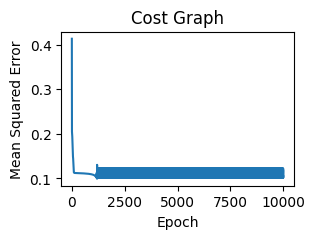

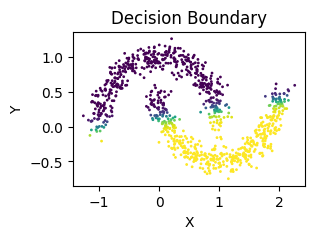

In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

weights_input_output = 2 * np.random.random((2, 1)) - 1
bias_output = np.random.randn(1, 1)

cost_graph = []
for epoch in range(10000):
    output_layer = sigmoid(np.dot(inputs, weights_input_output) + bias_output)

    output_error = outputs - output_layer
    cost_graph.append(np.mean(np.square(output_error)))  # Mean Squared Error

    output_delta = output_error * sigmoid_derivative(output_layer)

    weights_input_output += inputs.T.dot(output_delta)
    bias_output += np.sum(output_delta, axis=0, keepdims=True)

plt.figure(figsize=(3, 2))
plt.plot(cost_graph)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Cost Graph")
plt.show()

plt.figure(figsize=(3, 2))
plt.scatter(x, y, c=output_layer, s=1, cmap='viridis')  # Use a colormap for better visualization
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Decision Boundary")
plt.show()

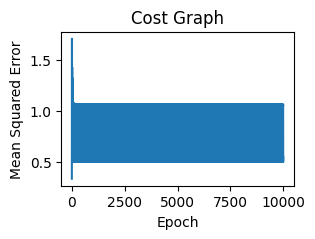

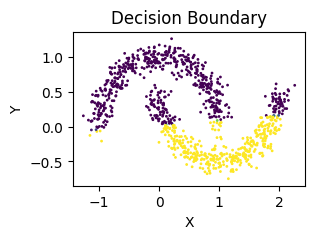

In [12]:
#Question 1
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

weights_input_output = 2 * np.random.random((2, 1)) - 1
bias_output = np.random.randn(1, 1)

cost_graph = []
for epoch in range(10000):
    output_layer = tanh(np.dot(inputs, weights_input_output) + bias_output)

    output_error = outputs - output_layer
    cost_graph.append(np.mean(np.square(output_error)))  # Mean Squared Error

    output_delta = output_error * tanh_derivative(output_layer)

    weights_input_output += inputs.T.dot(output_delta)
    bias_output += np.sum(output_delta, axis=0, keepdims=True)

plt.figure(figsize=(3, 2))
plt.plot(cost_graph)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Cost Graph")
plt.show()

plt.figure(figsize=(3, 2))
plt.scatter(x, y, c=output_layer, s=1, cmap='viridis')  # Use a colormap for better visualization
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Decision Boundary")
plt.show()

c:\Users\CL\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\CL\AppData\Local\Temp\ipykernel_16612\2583886627.py:17: RuntimeWarning: overflow encountered in square
  cost_graph.append(np.mean(np.square(output_error)))  # Mean Squared Error
c:\Users\CL\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\CL\AppData\Local\Temp\ipykernel_16612\2583886627.py:13: RuntimeWarning: invalid value encountered in add
  output_layer = relu(np.dot(inputs, weights_input_output) + bias_output)


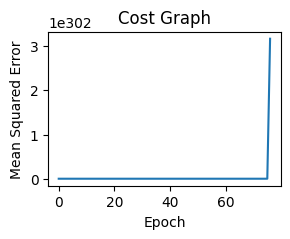

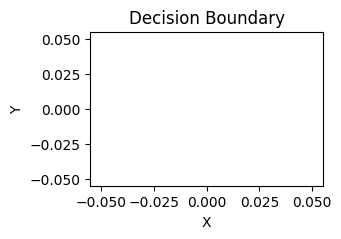

In [14]:
# Question 2
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

weights_input_output = 2 * np.random.random((2, 1)) - 1
bias_output = np.random.randn(1, 1)

cost_graph = []
for epoch in range(10000):
    output_layer = relu(np.dot(inputs, weights_input_output) + bias_output)


    output_error = outputs - output_layer
    cost_graph.append(np.mean(np.square(output_error)))  # Mean Squared Error

    output_delta = output_error * relu_derivative(output_layer)

    weights_input_output += inputs.T.dot(output_delta)
    bias_output += np.sum(output_delta, axis=0, keepdims=True)

plt.figure(figsize=(3, 2))
plt.plot(cost_graph)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Cost Graph")
plt.show()

plt.figure(figsize=(3, 2))
plt.scatter(x, y, c=output_layer, s=1, cmap='viridis')  # Use a colormap for better visualization
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Decision Boundary")
plt.show()

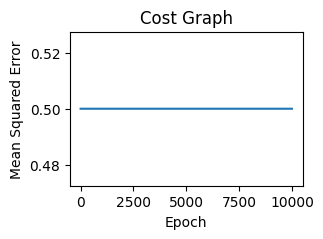

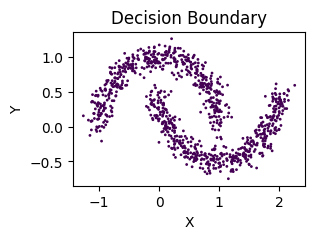

In [15]:
#Question 3
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # Subtract max for numerical stability
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def softmax_derivative(x):
    return x * (1 - x)  # This is a simplification and might not be entirely correct

weights_input_output = 2 * np.random.random((2, 1)) - 1
bias_output = np.random.randn(1, 1)

cost_graph = []
for epoch in range(10000):
    output_layer = softmax(np.dot(inputs, weights_input_output) + bias_output)


    output_error = outputs - output_layer
    cost_graph.append(np.mean(np.square(output_error)))  # Mean Squared Error

    output_delta = output_error * softmax_derivative(output_layer)

    weights_input_output += inputs.T.dot(output_delta)
    bias_output += np.sum(output_delta, axis=0, keepdims=True)

plt.figure(figsize=(3, 2))
plt.plot(cost_graph)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Cost Graph")
plt.show()

plt.figure(figsize=(3, 2))
plt.scatter(x, y, c=output_layer, s=1, cmap='viridis')  # Use a colormap for better visualization
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Decision Boundary")
plt.show()

--- Learning Rate: 1 ---
Minimum Error: 0.09968149695519092


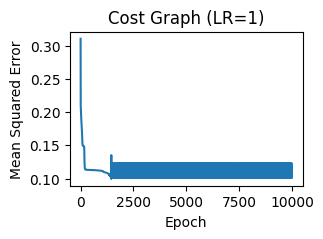

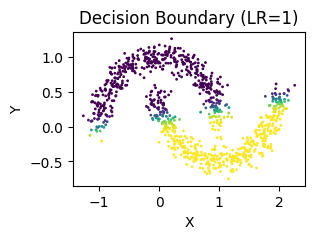

--- Learning Rate: 0.1 ---
Minimum Error: 0.0808948792689298


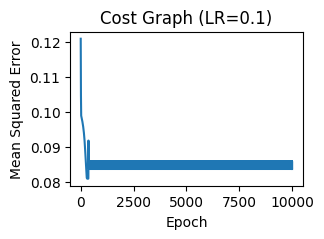

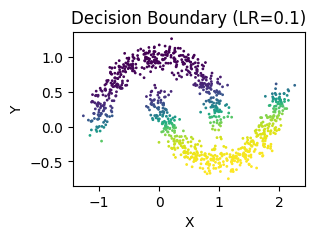

--- Learning Rate: 0.01 ---
Minimum Error: 0.08089481481670163


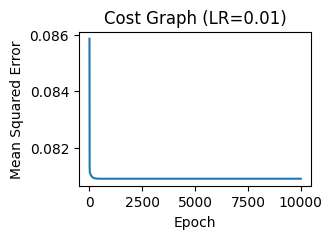

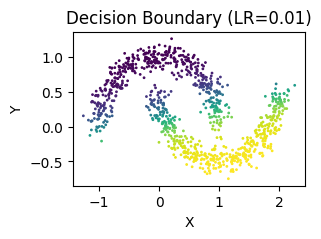

--- Learning Rate: 0.001 ---
Minimum Error: 0.08089481481670165


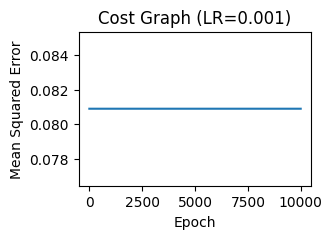

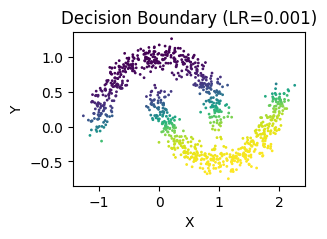

--- Learning Rate: 0.0001 ---
Minimum Error: 0.08089481481670165


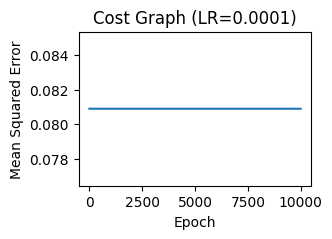

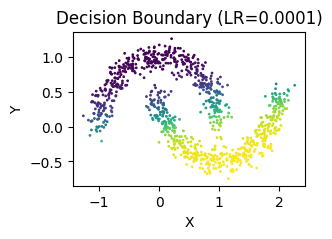

In [18]:
# Question 4

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

weights_input_output = 2 * np.random.random((2, 1)) - 1
bias_output = np.random.randn(1, 1)
learning_rates = [1, 0.1, 0.01, 0.001, 0.0001]

for lr in learning_rates:
    print(f"--- Learning Rate: {lr} ---")
    cost_graph = []

    # Training loop
    for epoch in range(10000):
        output_layer = sigmoid(np.dot(inputs, weights_input_output) + bias_output)

        output_error = outputs - output_layer
        cost_graph.append(np.mean(np.square(output_error)))

        output_delta = output_error * sigmoid_derivative(output_layer)

        weights_input_output += lr * inputs.T.dot(output_delta)
        bias_output += lr * np.sum(output_delta, axis=0, keepdims=True)

    min_error = min(cost_graph)
    print(f"Minimum Error: {min_error}")

    plt.figure(figsize=(3, 2))
    plt.plot(cost_graph)
    plt.xlabel("Epoch")
    plt.ylabel("Mean Squared Error")
    plt.title(f"Cost Graph (LR={lr})")
    plt.show()

    plt.figure(figsize=(3, 2))
    plt.scatter(x, y, c=output_layer, s=1, cmap='viridis')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Decision Boundary (LR={lr})")
    plt.show()

### Task 2: 1 Hidden Layer ANN Architecture

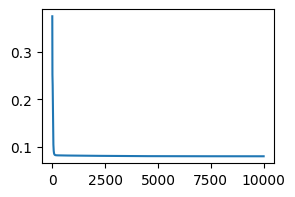

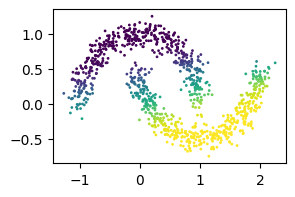

In [24]:
weights_input_hidden = 2 * np.random.random((2, 2)) - 1
weights_hidden_output = 2 * np.random.random((2, 1)) - 1
bias_hidden = np.random.randn(1, 2)
bias_output = np.random.randn(1, 1)
cost_graph = []
lr = 0.01
for epoch in range(10000):
    
   hidden_layer = sigmoid(np.dot(inputs, weights_input_hidden) + bias_hidden)
   output_layer = sigmoid(np.dot(hidden_layer, weights_hidden_output) + bias_output)

   output_error = outputs - output_layer
   cost_graph.append(np.mean(np.square(output_error)))
   output_delta = output_error * sigmoid_derivative(output_layer)
   hidden_delta = output_delta.dot(weights_hidden_output.T) * sigmoid_derivative(hidden_layer)
   weights_hidden_output += lr * hidden_layer.T.dot(output_delta)
   weights_input_hidden += lr * inputs.T.dot(hidden_delta)
   bias_output += lr * np.sum(output_delta, axis=0, keepdims=True)
   bias_hidden += lr * np.sum(hidden_delta, axis=0, keepdims=True)
plt.figure(figsize=(3, 2))
plt.plot(cost_graph)
plt.figure(figsize=(3, 2))
plt.scatter(x, y, c=output_layer, s=1)
plt.show()

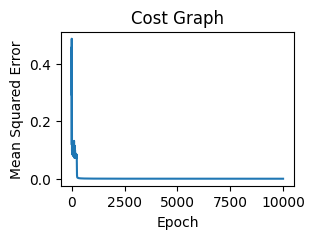

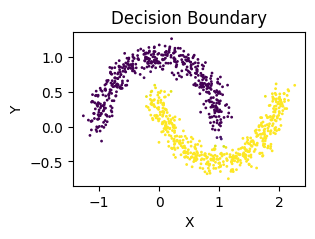

Minimum Error with 4 hidden neurons: 3.262218409647189e-05


In [26]:
# Question 4
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

input_size = 2
hidden_size = 4 
output_size = 1

weights_input_hidden = 2 * np.random.random((input_size, hidden_size)) - 1
weights_hidden_output = 2 * np.random.random((hidden_size, output_size)) - 1
bias_hidden = np.random.randn(1, hidden_size)
bias_output = np.random.randn(1, output_size)

lr = 0.1
epochs = 10000
cost_graph = []

for epoch in range(epochs):
    # Forward propagation
    hidden_layer_activation = sigmoid(np.dot(inputs, weights_input_hidden) + bias_hidden)
    output_layer = sigmoid(np.dot(hidden_layer_activation, weights_hidden_output) + bias_output)

    # Compute cost (Mean Squared Error)
    output_error = outputs - output_layer
    cost = np.mean(np.square(output_error))
    cost_graph.append(cost)

    # Backpropagation
    output_delta = output_error * sigmoid_derivative(output_layer)
    hidden_layer_error = output_delta.dot(weights_hidden_output.T)
    hidden_layer_delta = hidden_layer_error * sigmoid_derivative(hidden_layer_activation)

    # Update weights and biases
    weights_hidden_output += lr * hidden_layer_activation.T.dot(output_delta)
    bias_output += lr * np.sum(output_delta, axis=0, keepdims=True)
    weights_input_hidden += lr * inputs.T.dot(hidden_layer_delta)
    bias_hidden += lr * np.sum(hidden_layer_delta, axis=0, keepdims=True)

# Plotting the cost graph
plt.figure(figsize=(3, 2))
plt.plot(cost_graph)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Cost Graph")
plt.show()

# Plotting the decision boundary
plt.figure(figsize=(3, 2))
plt.scatter(x, y, c=output_layer, s=1, cmap='viridis')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Decision Boundary")
plt.show()

# Report the minimum error
min_error = min(cost_graph)
print(f"Minimum Error with 4 hidden neurons: {min_error}")

In [27]:
# Question 5 and 6
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

hidden_layer_sizes = [2, 8, 16, 20, 24]
learning_rates = [1, 0.1, 0.01, 0.001]
results = {}

for hidden_size in hidden_layer_sizes:
    results[hidden_size] = {}
    for lr in learning_rates:
        print(f"Training with Hidden Size: {hidden_size}, Learning Rate: {lr}")

        input_size = 2
        output_size = 1
        weights_input_hidden = 2 * np.random.random((input_size, hidden_size)) - 1
        weights_hidden_output = 2 * np.random.random((hidden_size, output_size)) - 1
        bias_hidden = np.random.randn(1, hidden_size)
        bias_output = np.random.randn(1, output_size)

        epochs = 10000
        cost_graph = []

        for epoch in range(epochs):
            hidden_layer_activation = sigmoid(np.dot(inputs, weights_input_hidden) + bias_hidden)
            output_layer = sigmoid(np.dot(hidden_layer_activation, weights_hidden_output) + bias_output)

            output_error = outputs - output_layer
            cost = np.mean(np.square(output_error))
            cost_graph.append(cost)

            output_delta = output_error * sigmoid_derivative(output_layer)
            hidden_layer_error = output_delta.dot(weights_hidden_output.T)
            hidden_layer_delta = hidden_layer_error * sigmoid_derivative(hidden_layer_activation)

            weights_hidden_output += lr * hidden_layer_activation.T.dot(output_delta)
            bias_output += lr * np.sum(output_delta, axis=0, keepdims=True)
            weights_input_hidden += lr * inputs.T.dot(hidden_layer_delta)
            bias_hidden += lr * np.sum(hidden_layer_delta, axis=0, keepdims=True)

        min_error = min(cost_graph)
        results[hidden_size][lr] = min_error
        print(f"Minimum Error: {min_error}\n")

print("Reported Minimum Errors:")
print("-----------------------------------------------------")
print("Hidden Layer Size / Learning Rate | 2       | 8       | 16      | 20      | 24      |")
print("-----------------------------------------------------")
for lr in learning_rates:
    row = f"{lr:<30}"
    for hidden_size in hidden_layer_sizes:
        row += f"| {results[hidden_size][lr]:<7.5f} "
    print(row + "|")
print("-----------------------------------------------------")

overall_min_error = float('inf')
best_hidden_size = None
best_learning_rate = None

for hidden_size, lr_errors in results.items():
    for lr, error in lr_errors.items():
        if error < overall_min_error:
            overall_min_error = error
            best_hidden_size = hidden_size
            best_learning_rate = lr

print(f"\nOverall Minimum Error: {overall_min_error:.5f}")
print(f"Achieved with Hidden Layer Size: {best_hidden_size} and Learning Rate: {best_learning_rate}")

Training with Hidden Size: 2, Learning Rate: 1
Minimum Error: 0.3028877866543871

Training with Hidden Size: 2, Learning Rate: 0.1
Minimum Error: 0.0743750258509365

Training with Hidden Size: 2, Learning Rate: 0.01
Minimum Error: 0.0705933196757346

Training with Hidden Size: 2, Learning Rate: 0.001
Minimum Error: 0.08147538420473568

Training with Hidden Size: 8, Learning Rate: 1
Minimum Error: 0.36770187160515533

Training with Hidden Size: 8, Learning Rate: 0.1
Minimum Error: 2.7941396821885483e-05

Training with Hidden Size: 8, Learning Rate: 0.01
Minimum Error: 0.0003280812547571901

Training with Hidden Size: 8, Learning Rate: 0.001
Minimum Error: 0.08117003763955981

Training with Hidden Size: 16, Learning Rate: 1
Minimum Error: 0.4663920122524174

Training with Hidden Size: 16, Learning Rate: 0.1
Minimum Error: 0.30556585438142847

Training with Hidden Size: 16, Learning Rate: 0.01
Minimum Error: 0.00045527417906700176

Training with Hidden Size: 16, Learning Rate: 0.001
Minim

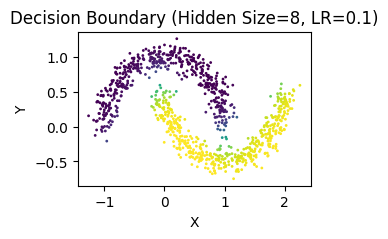

In [28]:
plt.figure(figsize=(3, 2))
plt.scatter(x, y, c=output_layer, s=1, cmap='viridis')
plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Decision Boundary (Hidden Size={best_hidden_size}, LR={best_learning_rate})")
plt.show()

### Task 3: 2 Hidden Layers ANN Architecture

In [30]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

learning_rates = [0.2, 0.5, 0.7, 1.0]
hidden_layer1_sizes = [4, 8, 12]
hidden_layer2_sizes = [4, 8, 12]

results = {}

for lr in learning_rates:
    results[lr] = {}
    print(f"\n--- Learning Rate: {lr} ---")

    for hidden1_size in hidden_layer1_sizes:
        results[lr][hidden1_size] = {}

        for hidden2_size in hidden_layer2_sizes:
            print(f"  Trying Hidden1: {hidden1_size}, Hidden2: {hidden2_size}")

            input_size = 2
            output_size = 1
            weights_input_hidden1 = 2 * np.random.random((input_size, hidden1_size)) - 1
            weights_hidden1_hidden2 = 2 * np.random.random((hidden1_size, hidden2_size)) - 1
            weights_hidden2_output = 2 * np.random.random((hidden2_size, output_size)) - 1
            bias_hidden1 = np.random.randn(1, hidden1_size)
            bias_hidden2 = np.random.randn(1, hidden2_size)
            bias_output = np.random.randn(1, output_size)

            epochs = 5000
            cost_graph = []

            for epoch in range(epochs):
                hidden_layer1 = sigmoid(np.dot(inputs, weights_input_hidden1) + bias_hidden1)
                hidden_layer2 = sigmoid(np.dot(hidden_layer1, weights_hidden1_hidden2) + bias_hidden2)
                output_layer = sigmoid(np.dot(hidden_layer2, weights_hidden2_output) + bias_output)

                output_error = outputs - output_layer
                cost = np.mean(np.square(output_error))
                cost_graph.append(cost)

                output_delta = output_error * sigmoid_derivative(output_layer)
                hidden2_error = output_delta.dot(weights_hidden2_output.T)
                hidden2_delta = hidden2_error * sigmoid_derivative(hidden_layer2)
                hidden1_error = hidden2_delta.dot(weights_hidden1_hidden2.T)
                hidden1_delta = hidden1_error * sigmoid_derivative(hidden_layer1)

                weights_hidden2_output += lr * hidden_layer2.T.dot(output_delta)
                weights_hidden1_hidden2 += lr * hidden_layer1.T.dot(hidden2_delta)
                weights_input_hidden1 += lr * inputs.T.dot(hidden1_delta)

                bias_hidden1 += lr * np.sum(hidden1_delta, axis=0, keepdims=True)
                bias_hidden2 += lr * np.sum(hidden2_delta, axis=0, keepdims=True)
                bias_output += lr * np.sum(output_delta, axis=0, keepdims=True)

            min_error = min(cost_graph)
            results[lr][hidden1_size][hidden2_size] = min_error
            print(f"    Min Error: {min_error}")

best_lr = None
best_hidden1_size = None
best_hidden2_size = None
best_min_error = float('inf')

for lr in results:
    for hidden1_size in results[lr]:
        for hidden2_size in results[lr][hidden1_size]:
            error = results[lr][hidden1_size][hidden2_size]
            if error < best_min_error:
                best_min_error = error
                best_lr = lr
                best_hidden1_size = hidden1_size
                best_hidden2_size = hidden2_size

print("\n--- Best Configuration ---")
print(f"Learning Rate: {best_lr}")
print(f"Hidden Layer 1 Size: {best_hidden1_size}")
print(f"Hidden Layer 2 Size: {best_hidden2_size}")
print(f"Minimum Error: {best_min_error}")


--- Learning Rate: 0.2 ---
  Trying Hidden1: 4, Hidden2: 4
    Min Error: 0.34782750959392233
  Trying Hidden1: 4, Hidden2: 8
    Min Error: 0.34951434842648177
  Trying Hidden1: 4, Hidden2: 12
    Min Error: 0.26582280165817146
  Trying Hidden1: 8, Hidden2: 4
    Min Error: 0.25277054014360684
  Trying Hidden1: 8, Hidden2: 8
    Min Error: 0.41068581042450253
  Trying Hidden1: 8, Hidden2: 12
    Min Error: 0.34421238172298263
  Trying Hidden1: 12, Hidden2: 4
    Min Error: 0.2810273579050705
  Trying Hidden1: 12, Hidden2: 8
    Min Error: 0.3333080327345461
  Trying Hidden1: 12, Hidden2: 12
    Min Error: 0.2537010118398114

--- Learning Rate: 0.5 ---
  Trying Hidden1: 4, Hidden2: 4
    Min Error: 0.28141687025340323
  Trying Hidden1: 4, Hidden2: 8
    Min Error: 0.3727429220797399
  Trying Hidden1: 4, Hidden2: 12
    Min Error: 0.311498057383596
  Trying Hidden1: 8, Hidden2: 4
    Min Error: 0.2948085317937056
  Trying Hidden1: 8, Hidden2: 8
    Min Error: 0.243664337305907
  Trying

### Task 4: Change the Dataset

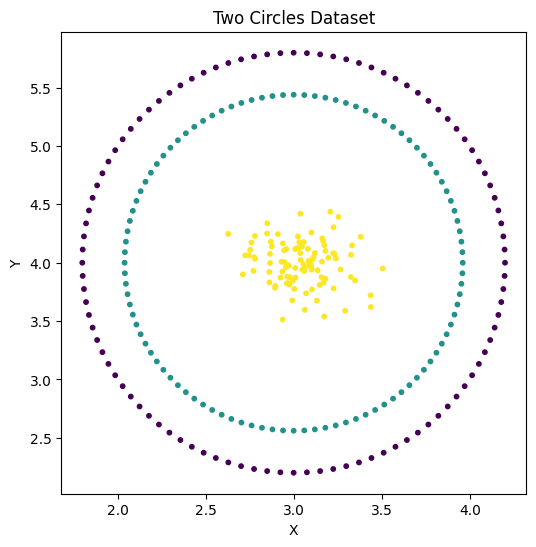

In [31]:
points = np.genfromtxt('two-circles.csv', delimiter=',')
points = points[1:len(points)]

x = points[:, 0]
y = points[:, 1]
labels = points[:, 2]

plt.figure(figsize=(6, 6))
plt.scatter(x, y, c=labels, s=10)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Two Circles Dataset")
plt.show()